# Experiment 6 — XGBoost Feature Engineering Playground

Sandbox for exploring feature engineering on top of the existing XGBoost counterfactual pipeline.

Current production features (`XGB_FEATURES`):
- `average_watts` — rider power output
- `average_grade` — segment grade %
- `doy_sin` / `doy_cos` — cyclical day-of-year (seasonality)
- `ride_index` — days since first recorded effort (fitness trend proxy)

**Goal:** experiment with candidate features and see whether they improve out-of-sample speed prediction before promoting them into `src/bike_delta.py`.

## 1. Imports

In [16]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

from src.database import init_db, load_efforts, load_segments, load_bikes
from src.bike_delta import (
    prepare_delta_dataset,
    XGB_FEATURES,
)
from src.analytics import filter_outliers_by_power_speed, apply_min_watts_filter

sns.set_theme(style="whitegrid", palette="Set2")
print("Imports OK")
print(f"Current XGB_FEATURES: {XGB_FEATURES}")

Imports OK
Current XGB_FEATURES: ['average_watts', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos']


## 2. Load and Inspect Data

In [17]:
init_db()
uid = '56163722'
raw_efforts = load_efforts(uid)
segments    = load_segments(uid)
bikes_df    = load_bikes(uid)
bikes_dict  = bikes_df[0]

df_raw = prepare_delta_dataset(raw_efforts, segments, bikes_dict)
df, _  = filter_outliers_by_power_speed(df_raw, z_threshold=3.0)
df = apply_min_watts_filter(
    df,
    int(180),
    descents_exempt=True,
)
print(f"Efforts after outlier filter: {len(df):,}")
print(f"Bikes: {df['bike_name'].unique().tolist()}")
df.head()

Efforts after outlier filter: 2,263
Bikes: ['Titanium Horse', 'Drew bike', 'Canyon Aeroad CF SLX', 'Specialized Tarmac SL8']


,athlete_id,effort_id,segment_id,activity_id,gear_id,start_date,elapsed_time,moving_time,average_watts,average_heartrate,...,climb_category,hazardous,total_elevation_gain,speed_kmh,speed_per_cbrt_watt,ride_index,doy_sin,doy_cos,is_outlier,z_score
0,56163722,2738902926331655910,16679484,4036869360,b7576250,2020-09-09T21:09:11Z,477,477,278.6,NaN,...,0,0,33.4,34.870943,5.339124,0.0,-0.936881,-0.349647,False,2.295720
2,56163722,2738902926332015334,16679746,4036869360,b7576250,2020-09-09T21:21:46Z,248,248,189.7,NaN,...,0,0,1.0,33.876290,5.895764,0.0,-0.936881,-0.349647,False,1.237701
3,56163722,2738902926334544614,17163284,4036869360,b7576250,2020-09-09T21:25:17Z,70,70,258.7,NaN,...,0,0,12.6,28.563429,4.482754,0.0,-0.936881,-0.349647,False,1.386698
4,56163722,2738902926334964454,16679494,4036869360,b7576250,2020-09-09T21:13:03Z,148,148,229.3,NaN,...,0,0,1.4,36.038919,5.888035,0.0,-0.936881,-0.349647,False,1.528563
12,56163722,3263157621456283542,17015237,12246925159,b7576250,2024-08-26T14:04:04Z,633,633,219.1,126.6,...,0,0,17.4,30.059147,4.986118,1446.0,-0.826354,-0.563151,False,0.481970


In [18]:
df.columns

Index(['athlete_id', 'effort_id', 'segment_id', 'activity_id', 'gear_id',
       'start_date', 'elapsed_time', 'moving_time', 'average_watts',
       'average_heartrate', 'bike_name', 'distance', 'average_grade',
       'maximum_grade', 'segment_type', 'segment_type_detail',
       'climb_category', 'hazardous', 'total_elevation_gain', 'speed_kmh',
       'speed_per_cbrt_watt', 'ride_index', 'doy_sin', 'doy_cos', 'is_outlier',
       'z_score'],
      dtype='str')

In [19]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 2263 entries, 0 to 2518
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   athlete_id            2263 non-null   int64  
 1   effort_id             2263 non-null   int64  
 2   segment_id            2263 non-null   int64  
 3   activity_id           2263 non-null   int64  
 4   gear_id               2263 non-null   str    
 5   start_date            2263 non-null   str    
 6   elapsed_time          2263 non-null   int64  
 7   moving_time           2263 non-null   int64  
 8   average_watts         2263 non-null   float64
 9   average_heartrate     2147 non-null   float64
 10  bike_name             2263 non-null   str    
 11  distance              2263 non-null   float64
 12  average_grade         2263 non-null   float64
 13  maximum_grade         2263 non-null   float64
 14  segment_type          2263 non-null   str    
 15  segment_type_detail   2263 non-null  

,athlete_id,effort_id,segment_id,activity_id,elapsed_time,moving_time,average_watts,average_heartrate,distance,average_grade,maximum_grade,climb_category,hazardous,total_elevation_gain,speed_kmh,speed_per_cbrt_watt,ride_index,doy_sin,doy_cos,z_score
count,2263.0,2.263000e+03,2.263000e+03,2.263000e+03,2263.000000,2263.000000,2263.000000,2147.000000,2263.000000,2263.000000,2263.000000,2263.000000,2263.0,2263.000000,2263.000000,2252.000000,2263.000000,2263.000000,2263.000000,2118.000000
mean,56163722.0,3.401277e+18,1.776312e+07,1.584573e+10,440.703933,436.190013,253.548387,136.601490,3476.785024,0.473221,9.772205,0.025188,0.0,24.863677,29.761957,5.150743,1827.346443,0.159876,-0.236677,-0.050417
std,0.0,7.125069e+16,9.824229e+06,1.960801e+09,428.596988,422.934169,97.818674,16.675836,3336.032140,2.351896,10.690582,0.156730,0.0,26.725116,7.211044,3.928107,196.574015,0.713536,0.640075,0.909645
min,56163722.0,2.738903e+18,6.112560e+05,4.036869e+09,27.000000,27.000000,0.000000,63.900000,359.500000,-8.300000,-4.100000,0.000000,0.0,1.000000,9.497975,1.560802,0.000000,-0.999769,-0.999963,-2.964142
25%,56163722.0,3.358105e+18,1.184173e+07,1.448893e+10,78.000000,78.000000,210.350000,124.500000,555.400000,0.000000,3.400000,0.000000,0.0,5.000000,26.238416,4.215408,1708.000000,-0.559589,-0.838280,-0.677569
50%,56163722.0,3.393993e+18,1.667975e+07,1.554794e+10,232.000000,230.000000,238.900000,134.000000,1661.100000,0.100000,5.500000,0.000000,0.0,15.600000,29.167826,4.736019,1807.000000,0.345612,-0.365723,-0.126176
75%,56163722.0,3.471058e+18,1.882464e+07,1.782575e+10,661.000000,656.500000,276.450000,147.000000,5285.400000,1.500000,13.500000,0.000000,0.0,38.000000,32.689655,5.146277,2020.000000,0.849817,0.259512,0.542918
max,56163722.0,3.502475e+18,3.800313e+07,1.896495e+10,1841.000000,1755.000000,1003.400000,195.800000,11932.100000,8.400000,46.500000,1.000000,0.0,107.200000,58.320000,58.492591,2107.000000,0.999917,0.996298,2.640722


## 3. Feature Engineering

Add candidate features here. The block below engineers a set of starting ideas — comment out / add freely.

**Candidate ideas:**
- `log_watts` — log transform to compress power outliers
- `watts_per_grade` — power efficiency on a given slope
- `distance_km` — segment length (longer = more aerodynamic drag matters)
- `elapsed_ratio` — elapsed / moving time (stop-time proxy)
- `heartrate` — fatigue / exertion proxy (when available)
- `week_of_year_sin/cos` — finer periodicity than doy
- `effort_avg_speed` - attempt to control for if its a flat after a descent or something
- `segment type`
- `cadence`
- `geometry of segment`

In [20]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add candidate features to the prepared dataset.
    Edit freely — comment out or add columns as you experiment.
    """
    out = df.copy()
    ts = pd.to_datetime(out["start_date"], errors="coerce", utc=True).dt.tz_convert(None)

    # ── Power transforms ──────────────────────────────────────────────────────
    out["log_watts"] = np.log1p(out["average_watts"])
    out["cbrt_watts"] = np.cbrt(out["average_watts"])
    
    # ── Interaction: power efficiency on a slope ──────────────────────────────
    safe_grade = out["average_grade"].replace(0, np.nan)
    out["watts_per_grade"] = out["average_watts"] / safe_grade.abs()

    # ── Segment length ────────────────────────────────────────────────────────
    if "distance" in out.columns:
        out["distance_km"] = out["distance"] / 1000.0

    # ── Pacing: elapsed vs moving time ───────────────────────────────────────
    if "elapsed_time" in out.columns and "moving_time" in out.columns:
        safe_moving = out["moving_time"].replace(0, np.nan)
        out["elapsed_ratio"] = out["elapsed_time"] / safe_moving

    # ── Heart rate (when available) ───────────────────────────────────────────
    if "average_heartrate" in out.columns:
        out["heartrate"] = out["average_heartrate"]

    # ── Finer cyclical seasonality (week of year) ─────────────────────────────
    woy = ts.dt.isocalendar().week.astype(float)
    out["woy_sin"] = np.sin(2 * np.pi * woy / 52.0)
    out["woy_cos"] = np.cos(2 * np.pi * woy / 52.0)

    # ── Cumulative effort count as fitness ramp proxy ─────────────────────────
    out = out.sort_values("start_date")
    out["effort_count"] = np.arange(1, len(out) + 1, dtype=float)

    # ── Month encoded cyclically ──────────────────────────────────────────────
    month = ts.dt.month.astype(float)
    out["month_sin"] = np.sin(2 * np.pi * month / 12.0)
    out["month_cos"] = np.cos(2 * np.pi * month / 12.0)

    dummies = pd.get_dummies(out["segment_type_detail"], prefix="segtype_detail", dummy_na=True, dtype=float)
    out = pd.concat([out, dummies], axis=1)

    dummies = pd.get_dummies(out["segment_type"], prefix="segtype", dummy_na=True, dtype=float)
    out = pd.concat([out, dummies], axis=1)
    
    return out.reset_index(drop=True)


df_feat = engineer_features(df)

# Show the new columns alongside existing ones
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(f"New features added: {new_cols}")
df_feat[XGB_FEATURES + new_cols].describe()

New features added: ['log_watts', 'cbrt_watts', 'watts_per_grade', 'distance_km', 'elapsed_ratio', 'heartrate', 'woy_sin', 'woy_cos', 'effort_count', 'month_sin', 'month_cos', 'segtype_detail_ascent_moderate', 'segtype_detail_ascent_shallow', 'segtype_detail_ascent_steep', 'segtype_detail_descent_steep', 'segtype_detail_flat_long', 'segtype_detail_flat_short', 'segtype_detail_sprint_downhill', 'segtype_detail_sprint_flat', 'segtype_detail_sprint_uphill', 'segtype_detail_nan', 'segtype_ascent', 'segtype_descent', 'segtype_flat', 'segtype_sprint', 'segtype_nan']


,average_watts,average_grade,maximum_grade,doy_sin,doy_cos,log_watts,cbrt_watts,watts_per_grade,distance_km,elapsed_ratio,...,segtype_detail_flat_short,segtype_detail_sprint_downhill,segtype_detail_sprint_flat,segtype_detail_sprint_uphill,segtype_detail_nan,segtype_ascent,segtype_descent,segtype_flat,segtype_sprint,segtype_nan
count,2263.000000,2263.000000,2263.000000,2263.000000,2263.000000,2263.000000,2263.000000,1653.000000,2263.000000,2263.000000,...,2263.000000,2263.000000,2263.000000,2263.000000,2263.0,2263.000000,2263.000000,2263.000000,2263.000000,2263.0
mean,253.548387,0.473221,9.772205,0.159876,-0.236677,5.424925,6.199446,677.209718,3.476785,1.007266,...,0.139196,0.051259,0.093681,0.214317,0.0,0.049934,0.039770,0.551038,0.359258,0.0
std,97.818674,2.351896,10.690582,0.713536,0.640075,0.682193,0.971601,793.798632,3.336032,0.035361,...,0.346227,0.220575,0.291449,0.410439,0.0,0.217856,0.195462,0.497498,0.479889,0.0
min,0.000000,-8.300000,-4.100000,-0.999769,-0.999963,0.000000,0.000000,0.000000,0.359500,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
25%,210.350000,0.000000,3.400000,-0.559589,-0.838280,5.353515,5.947222,113.954545,0.555400,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0
50%,238.900000,0.100000,5.500000,0.345612,-0.365723,5.480222,6.204956,283.625000,1.661100,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.0
75%,276.450000,1.500000,13.500000,0.849817,0.259512,5.625641,6.514367,1094.000000,5.285400,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,0.0
max,1003.400000,8.400000,46.500000,0.999917,0.996298,6.912146,10.011321,3514.000000,11.932100,1.575419,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.0


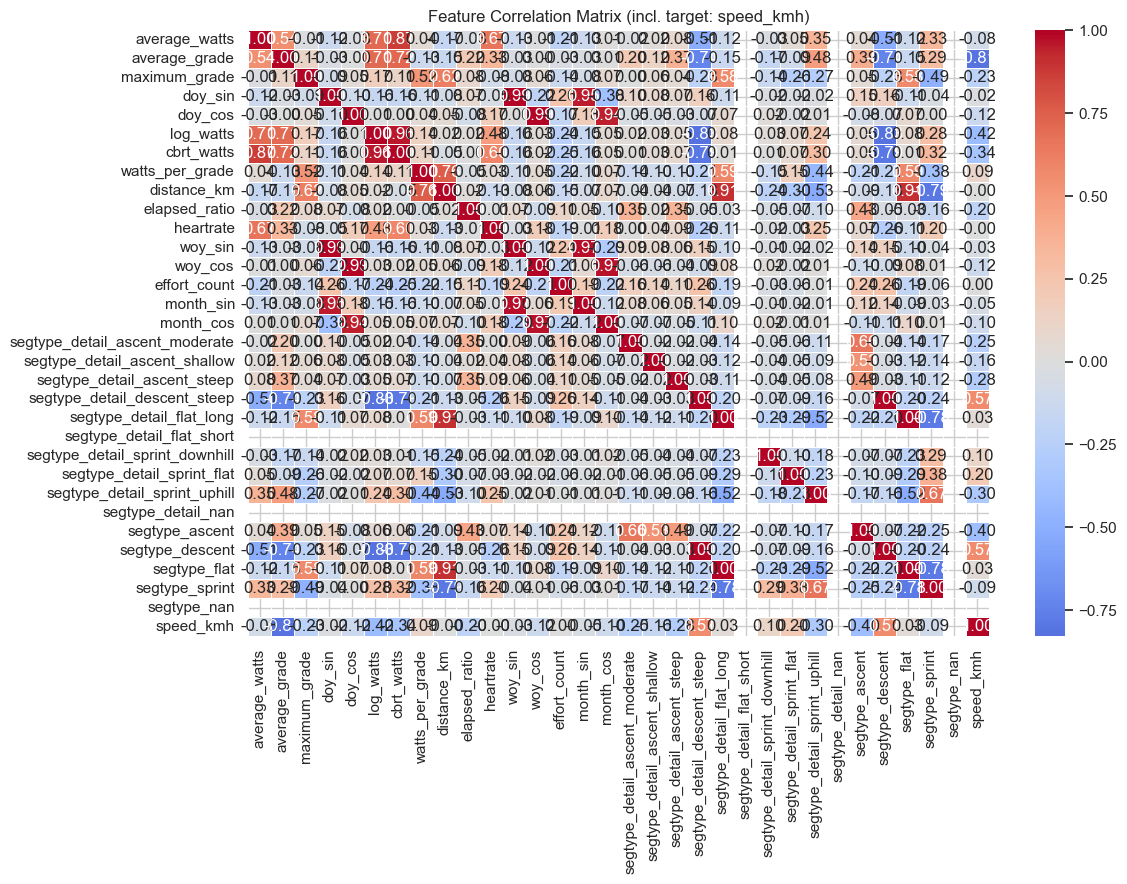

In [21]:
# Quick correlation heatmap of candidate features vs target (speed_kmh)
candidate_cols = XGB_FEATURES + new_cols + ["speed_kmh"]
corr = df_feat[candidate_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    center=0, cmap="coolwarm",
    linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Matrix (incl. target: speed_kmh)")
plt.tight_layout()
plt.show()

## 4. Train XGBoost Model

Trains per-bike models using the current production features and then with the expanded feature set so you can compare CV scores side by side.

In [22]:
XGB_FEATURES

['average_watts', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos']

In [23]:
new_cols

['log_watts',
 'cbrt_watts',
 'watts_per_grade',
 'distance_km',
 'elapsed_ratio',
 'heartrate',
 'woy_sin',
 'woy_cos',
 'effort_count',
 'month_sin',
 'month_cos',
 'segtype_detail_ascent_moderate',
 'segtype_detail_ascent_shallow',
 'segtype_detail_ascent_steep',
 'segtype_detail_descent_steep',
 'segtype_detail_flat_long',
 'segtype_detail_flat_short',
 'segtype_detail_sprint_downhill',
 'segtype_detail_sprint_flat',
 'segtype_detail_sprint_uphill',
 'segtype_detail_nan',
 'segtype_ascent',
 'segtype_descent',
 'segtype_flat',
 'segtype_sprint',
 'segtype_nan']

In [24]:
# ── Edit these to swap in/out candidate features ──────────────────────────────
EXPERIMENTAL_FEATURES = XGB_FEATURES + new_cols

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

cv = KFold(n_splits=2, shuffle=True, random_state=42)

def cv_metrics(feature_cols: list[str], df_in: pd.DataFrame) -> dict:
    """Return per-bike CV metrics dict (RMSE, MSE, R²) for the given feature set."""
    results = {}
    for bike in df_in["bike_name"].unique():
        sub = df_in[df_in["bike_name"] == bike].dropna(subset=feature_cols + ["speed_kmh"])
        if len(sub) < 200:
            continue
        X = sub[feature_cols].values
        y = sub["speed_kmh"].values
        model = xgb.XGBRegressor(**XGB_PARAMS)

        scores = cross_validate(model, X, y, cv=cv, scoring={
            "rmse": "neg_root_mean_squared_error",
            "mse":  "neg_mean_squared_error",
            "r2":   "r2",
            "mae": "neg_mean_absolute_error",
        })

        results[bike] = {
            "samples": len(sub),
            "rmse": -scores["test_rmse"].mean(),
            "mse":  -scores["test_mse"].mean(),
            "r2":    scores["test_r2"].mean(),
            "mae": -scores["test_mae"].mean(),
        }

    return results

baseline_metrics     = cv_metrics(XGB_FEATURES, df_feat)
experimental_metrics = cv_metrics(EXPERIMENTAL_FEATURES, df_feat)

rows = {}
for bike in set(baseline_metrics) | set(experimental_metrics):
    b = baseline_metrics.get(bike, {})
    e = experimental_metrics.get(bike, {})
    rows[bike] = {
        "samples": e.get("samples"),
        "delta_rmse": round(e["rmse"] - b["rmse"], 4) if b and e else None,
        "delta_mse":  round(e["mse"]  - b["mse"],  4) if b and e else None,
        "delta_r2":   round(e["r2"]   - b["r2"],   4) if b and e else None,
        "delta_mae":  round(e["mae"]  - b["mae"],  4) if b and e else None,
    }

compare = pd.DataFrame(rows).T.round(4)
compare["better_mae"] = compare["delta_mae"] < 0
compare["better_rmse"] = compare["delta_rmse"] < 0
compare["better_r2"]   = compare["delta_r2"]   > 0  # higher R² is better

# print(compare)
compare

,samples,delta_rmse,delta_mse,delta_r2,delta_mae,better_mae,better_rmse,better_r2
Titanium Horse,267.0,0.1365,0.6871,-0.0399,0.0152,False,False,False
Specialized Tarmac SL8,232.0,0.4147,4.7802,-0.0274,0.0571,False,False,False
Canyon Aeroad CF SLX,1051.0,0.0897,0.4056,0.0101,-0.0199,True,False,True


In [25]:
from sklearn.feature_selection import RFECV

def run_rfe(feature_cols: list[str], df_in: pd.DataFrame, min_samples: int = 10) -> dict:
    """Run RFECV per bike, return selected features and CV scores."""
    results = {}
    for bike in df_in["bike_name"].unique():
        sub = df_in[df_in["bike_name"] == bike].dropna(subset=feature_cols + ["speed_kmh"])
        if len(sub) < min_samples:
            continue
        X = sub[feature_cols].values
        y = sub["speed_kmh"].values

        selector = RFECV(
            estimator=xgb.XGBRegressor(**XGB_PARAMS),
            cv=cv,
            scoring="neg_root_mean_squared_error",
            min_features_to_select=3,
            n_jobs=-1,
        )
        selector.fit(X, y)

        selected = [f for f, s in zip(feature_cols, selector.support_) if s]
        results[bike] = {
            "selected_features": selected,
            "n_features":        selector.n_features_,
            "best_rmse":        -selector.cv_results_["mean_test_score"].max(),
        }

    return results

rfe_results = run_rfe(EXPERIMENTAL_FEATURES, df_feat, min_samples=200)

# ── Summary ───────────────────────────────────────────────────────────────────
for bike, res in rfe_results.items():
    print(f"\n{bike}")
    print(f"  Features selected : {res['n_features']} / {len(EXPERIMENTAL_FEATURES)}")
    print(f"  Best CV RMSE      : {res['best_rmse']:.4f}")
    print(f"  Selected          : {res['selected_features']}")

# ── Which features were selected most often across bikes ─────────────────────
from collections import Counter

feature_votes = Counter(
    f for res in rfe_results.values() for f in res["selected_features"]
)
votes_df = (
    pd.Series(feature_votes)
    .sort_values(ascending=False)
    .rename("bikes_selected_in")
    .to_frame()
)
votes_df["pct"] = (votes_df["bikes_selected_in"] / len(rfe_results) * 100).round(1)
print("\nFeature votes across all bikes:")
print(votes_df)


Titanium Horse
  Features selected : 14 / 31
  Best CV RMSE      : 2.4904
  Selected          : ['average_watts', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos', 'log_watts', 'watts_per_grade', 'distance_km', 'heartrate', 'woy_cos', 'effort_count', 'month_sin', 'month_cos', 'segtype_detail_sprint_uphill']

Canyon Aeroad CF SLX
  Features selected : 23 / 31
  Best CV RMSE      : 2.1473
  Selected          : ['average_watts', 'average_grade', 'maximum_grade', 'doy_sin', 'doy_cos', 'log_watts', 'cbrt_watts', 'watts_per_grade', 'distance_km', 'elapsed_ratio', 'heartrate', 'woy_sin', 'woy_cos', 'effort_count', 'month_sin', 'month_cos', 'segtype_detail_ascent_moderate', 'segtype_detail_descent_steep', 'segtype_detail_flat_long', 'segtype_detail_sprint_downhill', 'segtype_detail_sprint_flat', 'segtype_detail_sprint_uphill', 'segtype_ascent']

Specialized Tarmac SL8
  Features selected : 16 / 31
  Best CV RMSE      : 3.0127
  Selected          : ['average_watts', 'average_grade', 'max

In [41]:
cols_to_use = votes_df[votes_df["bikes_selected_in"] >= 2].index.tolist()
cols_to_use

['average_watts',
 'average_grade',
 'maximum_grade',
 'doy_sin',
 'doy_cos',
 'log_watts',
 'watts_per_grade',
 'distance_km',
 'heartrate',
 'effort_count',
 'segtype_detail_sprint_uphill',
 'woy_cos',
 'month_sin',
 'month_cos',
 'cbrt_watts',
 'woy_sin',
 'segtype_ascent',
 'segtype_detail_sprint_flat',
 'segtype_detail_sprint_downhill']

## 5. Evaluate Model Performance

Feature importances + residual distributions for the experimental model.

In [42]:
# Train a single full model (all data, no CV) for inspection
# Pick the bike with the most data as the representative model
bike_counts = df_feat.groupby("bike_name")["effort_id"].count().sort_values(ascending=False)
ref_bikes = bike_counts.index[0:3]

for ref_bike in ref_bikes:
    print(f"Training inspection model on: {ref_bike!r}  ({bike_counts[ref_bike]} efforts)")

    sub = df_feat[df_feat["bike_name"] == ref_bike].dropna(subset=EXPERIMENTAL_FEATURES + ["speed_kmh"])
    X_all = sub[EXPERIMENTAL_FEATURES].values
    X_selected = sub[cols_to_use].values
    X_base = sub[XGB_FEATURES].values
    y_all = sub["speed_kmh"].values

    inspection_model = xgb.XGBRegressor(**XGB_PARAMS)
    inspection_model.fit(X_all, y_all)

    selected_model = xgb.XGBRegressor(**XGB_PARAMS)
    selected_model.fit(X_selected, y_all)

    base_model = xgb.XGBRegressor(**XGB_PARAMS)
    base_model.fit(X_base, y_all)

    y_pred_all = inspection_model.predict(X_all)
    rmse_all   = mean_squared_error(y_all, y_pred_all)
    mae_all    = mean_absolute_error(y_all, y_pred_all)
    y_pred_selected = selected_model.predict(X_selected)
    rmse_selected   = mean_squared_error(y_all, y_pred_selected)
    mae_selected    = mean_absolute_error(y_all, y_pred_selected)
    y_pred_base = base_model.predict(X_base)
    rmse_base   = mean_squared_error(y_all, y_pred_base)
    mae_base    = mean_absolute_error(y_all, y_pred_base)
    print(f"Inspection Model Train RMSE: {rmse_all:.4f} km/h  |  MAE: {mae_all:.4f} km/h  (in-sample)")
    print(f"Selected Model Train RMSE: {rmse_selected:.4f} km/h  |  MAE: {mae_selected:.4f} km/h  (in-sample)")
    print(f"Base Model Train RMSE: {rmse_base:.4f} km/h  |  MAE: {mae_base:.4f} km/h  (in-sample)")
    print()

Training inspection model on: 'Canyon Aeroad CF SLX'  (1536 efforts)
Inspection Model Train RMSE: 1.0509 km/h  |  MAE: 0.7579 km/h  (in-sample)
Selected Model Train RMSE: 1.0719 km/h  |  MAE: 0.7630 km/h  (in-sample)
Base Model Train RMSE: 1.4109 km/h  |  MAE: 0.8758 km/h  (in-sample)

Training inspection model on: 'Titanium Horse'  (416 efforts)
Inspection Model Train RMSE: 0.1872 km/h  |  MAE: 0.3332 km/h  (in-sample)
Selected Model Train RMSE: 0.1964 km/h  |  MAE: 0.3458 km/h  (in-sample)
Base Model Train RMSE: 0.3662 km/h  |  MAE: 0.4670 km/h  (in-sample)

Training inspection model on: 'Specialized Tarmac SL8'  (281 efforts)
Inspection Model Train RMSE: 0.0497 km/h  |  MAE: 0.1760 km/h  (in-sample)
Selected Model Train RMSE: 0.0495 km/h  |  MAE: 0.1741 km/h  (in-sample)
Base Model Train RMSE: 0.1990 km/h  |  MAE: 0.3327 km/h  (in-sample)



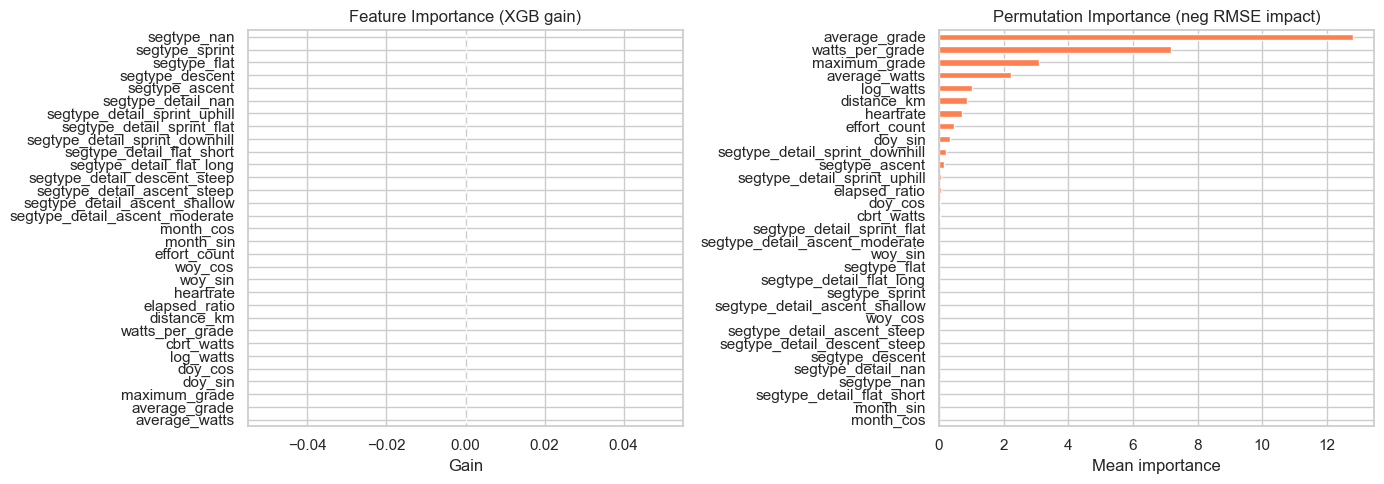

In [43]:
# ── XGBoost built-in feature importance (gain) ───────────────────────────────
imp_gain = pd.Series(
    inspection_model.get_booster().get_score(importance_type="gain"),
    name="gain",
).reindex(EXPERIMENTAL_FEATURES, fill_value=0).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_gain.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance (XGB gain)")
axes[0].set_xlabel("Gain")

# ── Permutation importance (more reliable for correlated features) ────────────
perm = permutation_importance(
    inspection_model, X_all, y_all,
    n_repeats=20, random_state=42, scoring="neg_root_mean_squared_error",
)
perm_df = pd.Series(perm.importances_mean, index=EXPERIMENTAL_FEATURES, name="perm").sort_values(ascending=True)
perm_df.plot.barh(ax=axes[1], color="coral")

axes[1].set_title("Permutation Importance (neg RMSE impact)")
axes[1].set_xlabel("Mean importance")

plt.tight_layout()
plt.show()

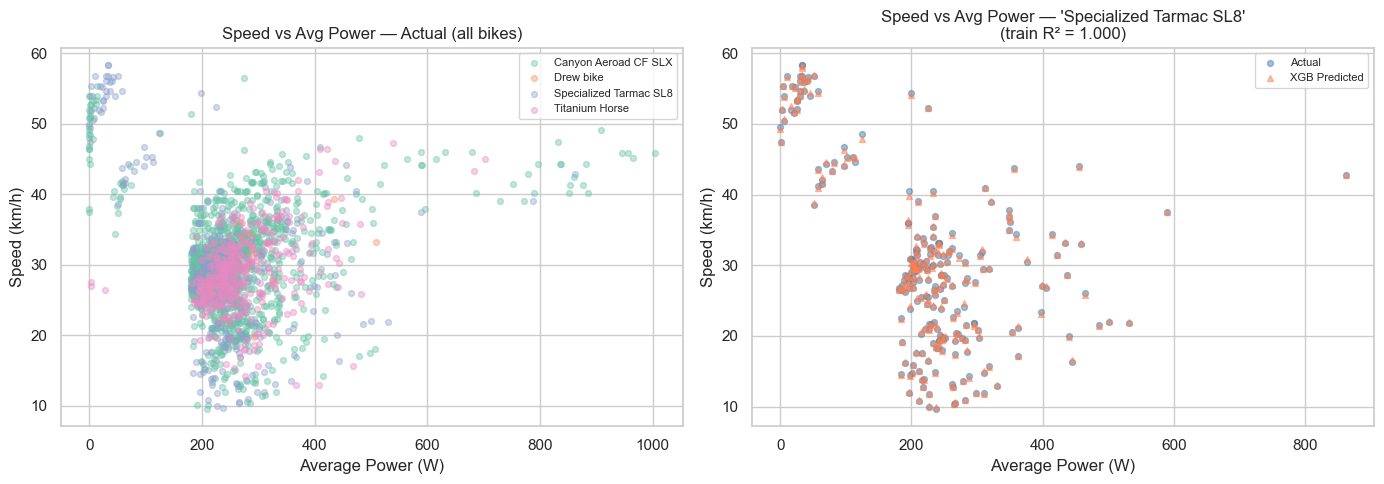

Train R²: 0.9997


In [44]:

# ── Speed vs Average Power (actual & XGB predicted) with R² ──────────────────
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual speed vs power, coloured by bike
for bike, grp in df_feat.groupby("bike_name"):
    axes[0].scatter(grp["average_watts"], grp["speed_kmh"],
                    alpha=0.4, s=18, label=bike)
axes[0].set_xlabel("Average Power (W)")
axes[0].set_ylabel("Speed (km/h)")
axes[0].set_title("Speed vs Avg Power — Actual (all bikes)")
axes[0].legend(fontsize=8)

# Right: XGB predicted vs actual for the reference bike (inspection_model)
sub_plot = df_feat[df_feat["bike_name"] == ref_bike].dropna(subset=EXPERIMENTAL_FEATURES + ["speed_kmh"])
r2_train = r2_score(y_all, y_pred_all)
axes[1].scatter(sub_plot["average_watts"], y_all,
                alpha=0.5, s=18, label="Actual", color="steelblue")
axes[1].scatter(sub_plot["average_watts"], y_pred_all,
                alpha=0.5, s=18, label="XGB Predicted", color="coral", marker="^")
axes[1].set_xlabel("Average Power (W)")
axes[1].set_ylabel("Speed (km/h)")
axes[1].set_title(f"Speed vs Avg Power — {ref_bike!r}\n(train R² = {r2_train:.3f})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"Train R²: {r2_train:.4f}")
